# Importacion de la librerias

In [39]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, classification_report

# Cargar los datos

In [2]:
data=('fraud_detection_dataset.csv')

In [3]:
df=pd.read_csv(data)

In [4]:
df.head()

,timestamp,user_id,amount,location,device_type,is_fraud,age,income,debt,credit_score
0,2023-12-15 02:48:24,3cbf0b8a-c799-4c0e-9782-89272ab8fa2b,998.99,Grantfurt,Mobile,0,56,42524.98,8394.05,655
1,2023-10-30 11:08:37,3675ed98-6863-4bae-b089-6f0db2df006b,241.39,Kimberlychester,Tablet,0,52,69884.04,28434.06,395
2,2023-11-21 05:19:35,4be1043f-20ee-4ac5-a689-b25c6a1de50c,836.42,Gutierrezville,Desktop,0,58,126953.62,39121.78,496
3,2023-11-07 00:03:25,cad0b3c9-099f-479b-8043-6d5ecb4e1467,612.74,Markside,Desktop,0,19,128650.70,39652.48,612
4,2023-04-02 14:12:23,b6ebea7d-ba62-41d7-b042-3978a23fef8b,135.55,Anthonyshire,Tablet,0,59,102020.39,7439.81,302


# Analisis exploratorio (Eda)

- timestamp: The date and time of the transaction / marca de tiempo. 
- user_id: A unique identifier for each user / la id de usuario.
- amount: The transaction amount in currency / cantidad transacciones recurrentes.
- location: The location where the transaction occurred (city)/ la localicacion de transacciones.
- device_type: The type of device used for the transaction (e.g., Desktop, Mobile, Tablet) / tipo de dispositivo.
- age: The age of the user / la edad del usuario.
- income: The income of the user / ingreso del usuario .
- debt: The debt amount associated with the user / deuda del usuario.
- credit_score: The credit score of the user / puntuacion del credito del usuario  .
- is_fraud: Binary indicator (0 or 1) representing whether the transaction is fraudulent (1) or legitimate (0) / ls marca si es fraude o legitima.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 10 columns):
 #   Column        Dtype  
---  ------        -----  
 0   timestamp     object 
 1   user_id       object 
 2   amount        float64
 3   location      object 
 4   device_type   object 
 5   is_fraud      int64  
 6   age           int64  
 7   income        float64
 8   debt          float64
 9   credit_score  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 152.6+ MB


In [11]:
print('datos vacios', df.isnull().sum().sum())

datos vacios 0


In [12]:
print("conjunto de datos: \n", df.shape)

conjunto de datos: 
 (2000000, 10)


In [13]:
df.describe()

,amount,is_fraud,age,income,debt,credit_score
count,2.000000e+06,2000000.0,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,1.751680e+03,0.5,4.400430e+01,8.502099e+04,2.498404e+04,5.747856e+02
std,1.504160e+03,0.5,1.529754e+01,3.753201e+04,1.444005e+04,1.591240e+02
min,1.000000e+01,0.0,1.800000e+01,2.000009e+04,4.000000e-02,3.000000e+02
25%,5.043400e+02,0.0,3.100000e+01,5.253058e+04,1.246551e+04,4.370000e+02
50%,1.000005e+03,0.5,4.400000e+01,8.503287e+04,2.498093e+04,5.750000e+02
75%,2.996710e+03,1.0,5.700000e+01,1.175375e+05,3.748029e+04,7.130000e+02
max,4.999990e+03,1.0,7.000000e+01,1.500000e+05,4.999998e+04,8.500000e+02


In [14]:
df.groupby('is_fraud').size()

is_fraud
0    1000000
1    1000000
dtype: int64

In [15]:
df.groupby('age').size()

age
18    37696
19    37902
20    37713
21    37944
22    37841
23    37455
24    37728
25    37641
26    37578
27    37649
28    37899
29    37582
30    37914
31    37764
32    37597
33    37446
34    37771
35    37941
36    37597
37    37782
38    37500
39    37851
40    37947
41    37753
42    37628
43    37488
44    37608
45    38022
46    37468
47    38189
48    37590
49    37349
50    37809
51    37936
52    37763
53    37766
54    37630
55    37991
56    37768
57    37733
58    37565
59    37906
60    37764
61    37853
62    38028
63    37647
64    37671
65    37714
66    37754
67    37935
68    37746
69    37613
70    37575
dtype: int64

In [15]:
#

# Preparacion de los datos 

In [5]:
df2=df.copy()

In [6]:
# df2['timestamp'] = pd.to_datetime(df2['timestamp'], errors='coerce')
# df2['timestamp'] = pd.to_datetime(df2['timestamp'], format='%d/%m/%Y')
df2['timestamp'] = pd.to_datetime(df2['timestamp'], errors='coerce')
df2['timestamp'] = df2['timestamp'].dt.strftime('%d/%m/%Y')
df2['timestamp'] = pd.to_datetime(df2['timestamp'], format='%d/%m/%Y')

In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 10 columns):
 #   Column        Dtype         
---  ------        -----         
 0   timestamp     datetime64[ns]
 1   user_id       object        
 2   amount        float64       
 3   location      object        
 4   device_type   object        
 5   is_fraud      int64         
 6   age           int64         
 7   income        float64       
 8   debt          float64       
 9   credit_score  int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 152.6+ MB


In [8]:
df2.head()

,timestamp,user_id,amount,location,device_type,is_fraud,age,income,debt,credit_score
0,2023-12-15,3cbf0b8a-c799-4c0e-9782-89272ab8fa2b,998.99,Grantfurt,Mobile,0,56,42524.98,8394.05,655
1,2023-10-30,3675ed98-6863-4bae-b089-6f0db2df006b,241.39,Kimberlychester,Tablet,0,52,69884.04,28434.06,395
2,2023-11-21,4be1043f-20ee-4ac5-a689-b25c6a1de50c,836.42,Gutierrezville,Desktop,0,58,126953.62,39121.78,496
3,2023-11-07,cad0b3c9-099f-479b-8043-6d5ecb4e1467,612.74,Markside,Desktop,0,19,128650.70,39652.48,612
4,2023-04-02,b6ebea7d-ba62-41d7-b042-3978a23fef8b,135.55,Anthonyshire,Tablet,0,59,102020.39,7439.81,302


In [43]:
feature_columns=['amount','age','income','debt','credit_score']
df2_agrupado = df2.groupby('timestamp')[feature_columns].agg(['mean', 'std'])

df2_agrupado.columns = [
    f'{agg_type.upper()}_{col}' for col, agg_type in df2_agrupado.columns
]

df2_agrupado.reset_index(inplace=True)

print(df2_agrupado.shape)
df2_agrupado.head()


# ***********************con_variable_fraude************************************

feature_columns2=['amount','age','income','debt','credit_score','is_fraud']
df2_agrupado2 = df2.groupby('timestamp')[feature_columns2].agg(['mean', 'std'])

df2_agrupado2.columns = [
    f'{agg_type.upper()}_{col}' for col, agg_type in df2_agrupado2.columns
]

df2_agrupado2.reset_index(inplace=True)

print(df2_agrupado2.shape)

(366, 11)
(366, 13)


# Entrenamiento del Isolation Forest

In [23]:
# Parametros
n_estimators = 500  # N_árboles
sample_size = 257  # Número de instancias usadas para entrenar cada árbol
# contamination = 0.09  # Proporción esperada de anomalías

In [24]:
# Seleccionar variables
features = df2_agrupado.drop('timestamp', axis=1)

# Entrenar el modelo Isolation Forest
iso_forest = IsolationForest(n_estimators=n_estimators,
                             # contamination=contamination,
                             max_samples=sample_size,
                             random_state=42)

iso_forest.fit(features)

IsolationForest(max_samples=257, n_estimators=500, random_state=42)

In [30]:
print('1 indica una instancia normal y -1 indica una anomalía')
df2_agrupado['anomaly_score'] = iso_forest.decision_function(features)
df2_agrupado['anomaly'] = iso_forest.predict(features)
df2_agrupado['anomaly'].value_counts()

1 indica una instancia normal y -1 indica una anomalía


anomaly
 1    332
-1     34
Name: count, dtype: int64

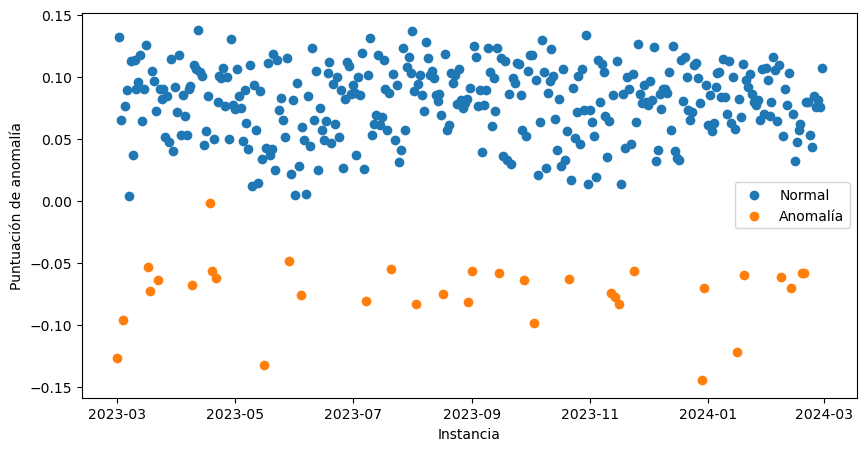

In [31]:
# Visualization of the results
plt.figure(figsize=(10, 5))

# Plot normal instances
normal = df2_agrupado[df2_agrupado['anomaly'] == 1]
plt.scatter(normal['timestamp'], normal['anomaly_score'], label='Normal')

# Plot anomalies
anomalies = df2_agrupado[df2_agrupado['anomaly'] == -1]
plt.scatter(anomalies['timestamp'], anomalies['anomaly_score'], label='Anomalía')

plt.xlabel("Instancia")
plt.ylabel("Puntuación de anomalía")
plt.legend()
plt.show()

### KernelSHAP

In [32]:
# Seleccionar al azar 100 instancias normales, y todas las de anomalías (8)
normal_sample = np.random.choice(normal.index,size=100,replace=False)
sample = np.append(anomalies.index,normal_sample)
len(sample)

134

In [33]:
# Uso de la puntuación de anomalía y KernelSHAP
explainer = shap.Explainer(iso_forest.decision_function, features)
shap_values = explainer(features.iloc[sample])

PermutationExplainer explainer: 135it [04:06,  1.91s/it]                         


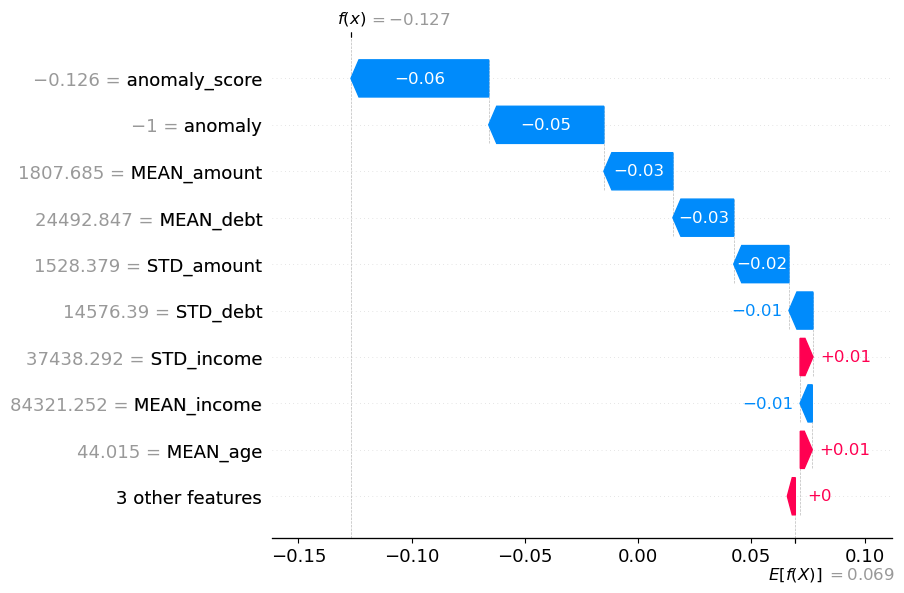

In [35]:
# Gráfico de cascada de una anomalía
shap.plots.waterfall(shap_values[0])

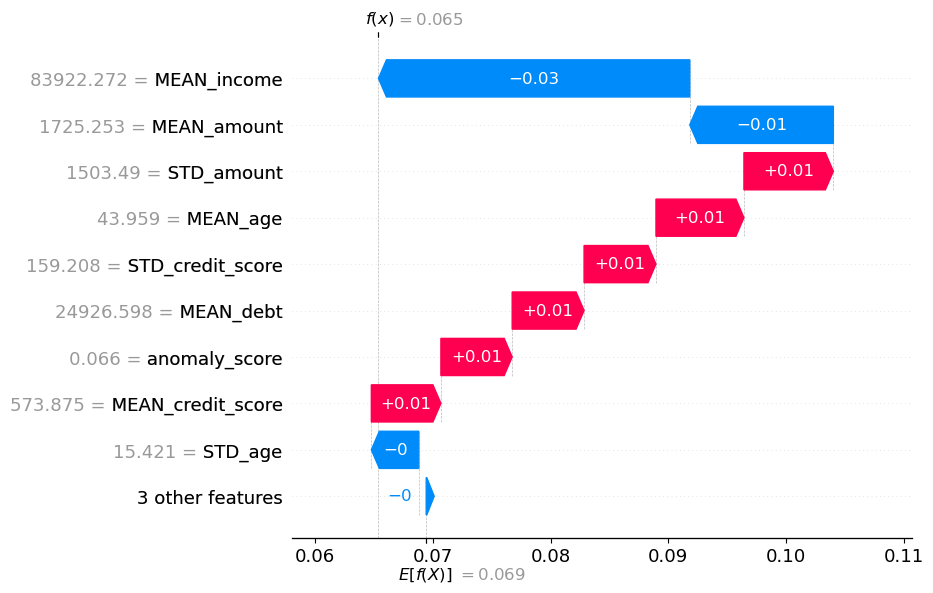

In [36]:
# Gráfico de cascada para una instancia normal
shap.plots.waterfall(shap_values[100])

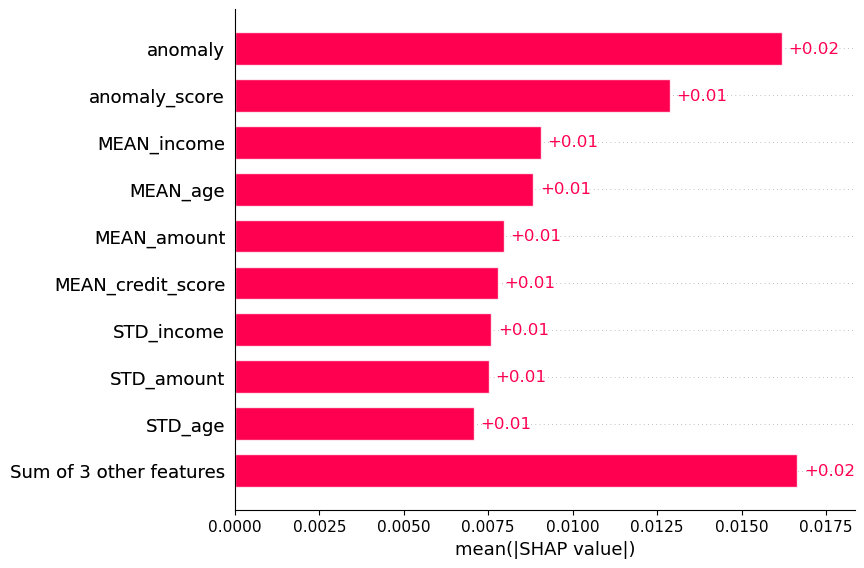

In [37]:
# Gráfico de medias de SHAP Plot
shap.plots.bar(shap_values)

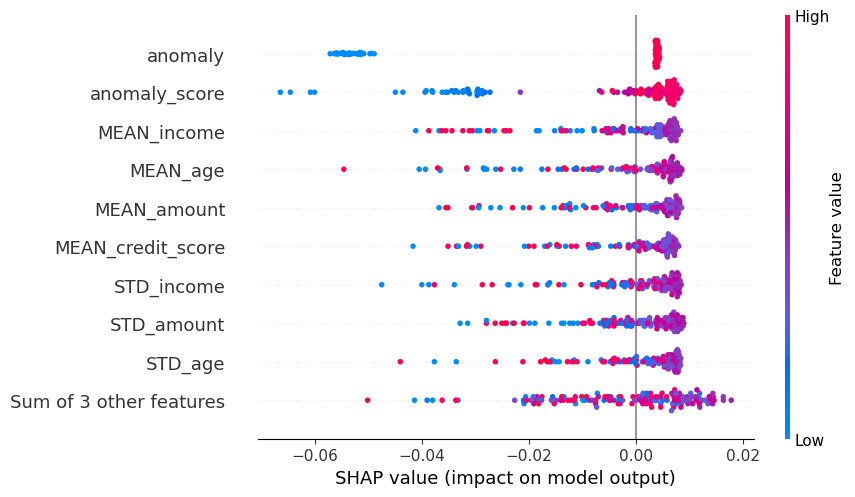

In [38]:
# Gráfico Beeswarm
shap.plots.beeswarm(shap_values)

In [46]:
df2_agrupado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          366 non-null    datetime64[ns]
 1   MEAN_amount        366 non-null    float64       
 2   STD_amount         366 non-null    float64       
 3   MEAN_age           366 non-null    float64       
 4   STD_age            366 non-null    float64       
 5   MEAN_income        366 non-null    float64       
 6   STD_income         366 non-null    float64       
 7   MEAN_debt          366 non-null    float64       
 8   STD_debt           366 non-null    float64       
 9   MEAN_credit_score  366 non-null    float64       
 10  STD_credit_score   366 non-null    float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 31.6 KB


In [47]:

df2_agrupado['anomaly'] = iso_forest.predict(features)

# valor de fraude real el el df
y_true = (df2_agrupado2['MEAN_is_fraud'] > 0).astype(int)

# Ajustar formato para evaluación: 1 para anomalía, 0 para normal
y_pred = [1 if x == -1 else 0 for x in df2_agrupado['anomaly']]

# Generar reporte (asumiendo que tienes 'y_true')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomalía']))

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
    Anomalía       1.00      0.09      0.17       366

    accuracy                           0.09       366
   macro avg       0.50      0.05      0.09       366
weighted avg       1.00      0.09      0.17       366



C:\Users\Christian\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Christian\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Christian\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
